In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

merged = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet")
print(merged.shape)
merged.head()

(66666, 54)


,OBJECT_NAME,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,NORAD_CAT_ID,BSTAR,MEAN_MOTION_DOT,SEMIMAJOR_AXIS,PERIOD,...,rx_km,ry_km,rz_km,vx_km_s,vy_km_s,vz_km_s,tle_age_days,altitude_km,speed_km_s,regime
0,OPS 3674 (VELA 4),2026-03-22T04:38:47.037408,0.23985689,0.57463450,48.7444,837,0.00000000000000,0.00000156,109420.923,6003.580,...,-87842.248216,66031.086790,40166.139083,-1.098975,-0.450464,1.326665,-4.0,110631.921857,1.780647,GEO
1,YZ-1 R/B,2026-03-22T00:05:53.344896,0.27910401,0.68547050,12.1133,41929,0.00000000000000,-0.00000606,98906.414,5159.367,...,-71978.947246,26862.548852,13005.642656,-2.142409,-1.165972,0.501345,-4.0,71550.191715,2.490131,GEO
2,ASTRON,2026-03-21T10:33:08.348544,0.24283977,0.65788428,78.4402,13901,0.00000000000000,0.00000203,108523.045,5929.836,...,-56540.136904,-127218.270086,-93797.684633,0.275027,0.036663,-0.999533,-3.0,161495.854880,1.037328,GEO
3,OPS 3662 (VELA 3),2026-03-20T19:37:22.087200,0.23902374,0.49573576,52.5257,836,0.00000000000000,0.00000640,109675.043,6024.506,...,-69574.444483,-75544.686826,128140.723117,0.671024,-0.859229,-0.177731,-3.0,157847.293602,1.104598,GEO
4,CXO,2026-03-20T11:08:23.080992,0.37808217,0.79854940,54.7244,25867,0.00000000000000,0.00001048,80787.538,3808.696,...,-25178.252625,-94524.345224,96227.317779,0.448764,-0.820913,0.023654,-2.0,130845.955703,0.935867,GEO


In [6]:
# redefining risk based on actual orbital properties
# not conjunction data
merged['PERIGEE'] = pd.to_numeric(merged['PERIGEE'], errors='coerce')
merged['BSTAR'] = pd.to_numeric(merged['BSTAR'], errors='coerce')
merged['ECCENTRICITY'] = pd.to_numeric(merged['ECCENTRICITY'], errors='coerce')

def get_risk_label(row):
    # high drag + low perigee = decaying fast = high risk
    if row['PERIGEE'] < 400 and abs(row['BSTAR']) > 0.0001:
        return 'HIGH'
    # medium altitude LEO with some drag
    elif row['PERIGEE'] < 600 and abs(row['BSTAR']) > 0.00001:
        return 'MEDIUM'
    # everything else
    else:
        return 'LOW'

merged['risk_label'] = merged.apply(get_risk_label, axis=1)
print(merged['risk_label'].value_counts())

risk_label
LOW       26366
HIGH      24571
MEDIUM    15729
Name: count, dtype: int64


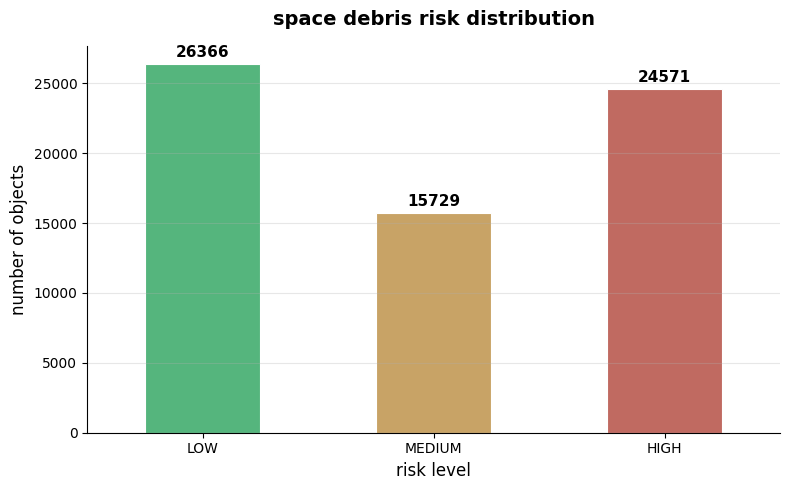

In [7]:
colors = ["#55b57d", "#c8a366", "#c06a61"]
bars = merged['risk_label'].value_counts().reindex(['LOW', 'MEDIUM', 'HIGH'])

plt.figure(figsize=(8, 5))
ax = bars.plot(kind='bar', color=colors, edgecolor='white', linewidth=0.8)

for i, v in enumerate(bars):
    ax.text(i, v + 500, str(v), ha='center', fontweight='bold', fontsize=11)

plt.title('space debris risk distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('risk level', fontsize=12)
plt.ylabel('number of objects', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
features = [
    'ECCENTRICITY', 'INCLINATION', 'MEAN_MOTION',
    'MEAN_MOTION_DOT', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOGEE',
    'RCSVALUE', 'altitude_km', 'speed_km_s',
    'attr_mass', 'attr_xSectAvg', 'tle_age_days'
]

features = [f for f in features if f in merged.columns]
X = merged[features].apply(pd.to_numeric, errors='coerce').fillna(0)
y = merged['risk_label']

print("X shape:", X.shape)

X shape: (66666, 13)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

        HIGH       0.93      0.96      0.94      4914
         LOW       0.96      0.95      0.95      5274
      MEDIUM       0.96      0.92      0.94      3146

    accuracy                           0.95     13334
   macro avg       0.95      0.94      0.94     13334
weighted avg       0.95      0.95      0.95     13334



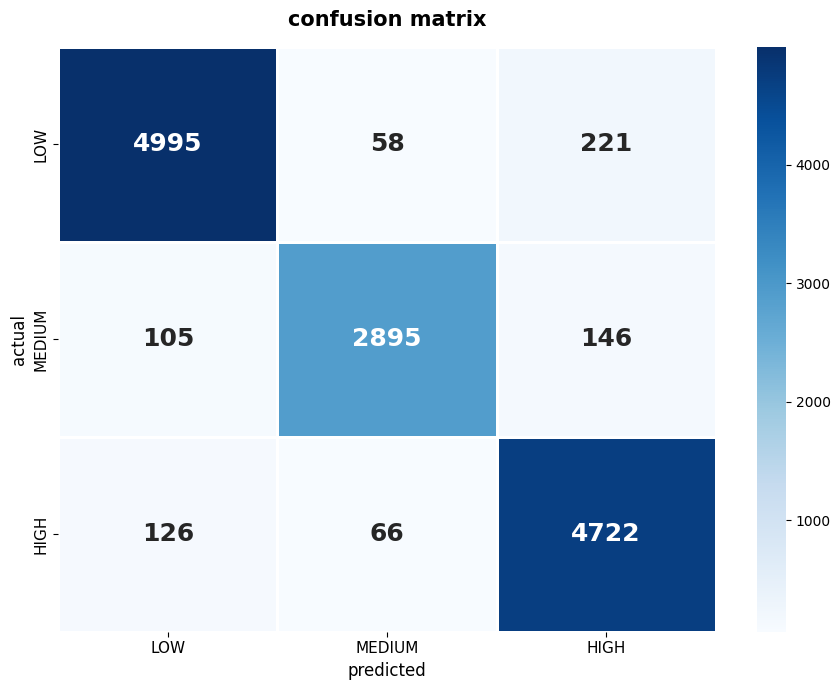

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred, labels=['LOW', 'MEDIUM', 'HIGH'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['LOW', 'MEDIUM', 'HIGH'],
            yticklabels=['LOW', 'MEDIUM', 'HIGH'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 18, 'weight': 'bold'},
            ax=ax)

ax.set_title('confusion matrix', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('actual', fontsize=12)
ax.set_xlabel('predicted', fontsize=12)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

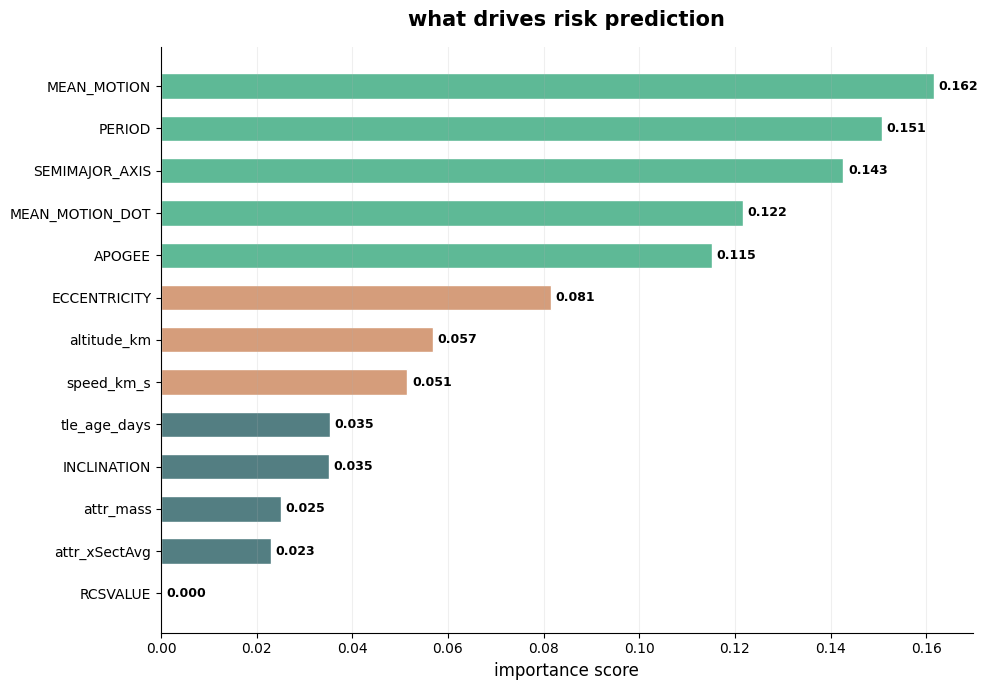

In [11]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(importance.index, importance.values, 
               color=["#5EB996" if v > 0.10 else "#d59d7b" if v > 0.05 else "#537e82" for v in importance.values],
               edgecolor='white', height=0.6)

for bar, val in zip(bars, importance.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.set_title('what drives risk prediction', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('importance score', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9525/285783809.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = sample_clean.groupby(['altitude_bin', 'risk_label'])['MEAN_MOTION'].mean().reset_index()


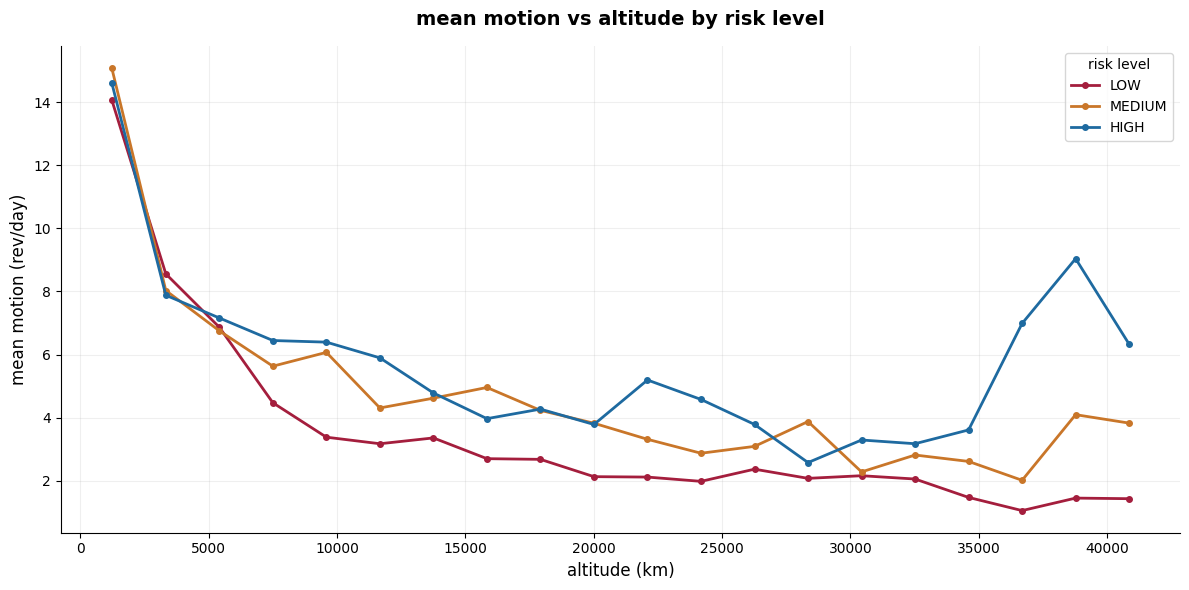

In [12]:
# bin altitude and plot mean motion trend
sample_clean = merged[(merged['altitude_km'].between(200, 42000))].copy()
sample_clean['altitude_bin'] = pd.cut(sample_clean['altitude_km'], bins=20)
sample_clean['MEAN_MOTION'] = pd.to_numeric(sample_clean['MEAN_MOTION'], errors='coerce')

trend = sample_clean.groupby(['altitude_bin', 'risk_label'])['MEAN_MOTION'].mean().reset_index()
trend['alt_mid'] = trend['altitude_bin'].apply(lambda x: x.mid)

fig, ax = plt.subplots(figsize=(12, 6))
for label, color in [('LOW', "#a41e3d"), ('MEDIUM', "#c97629"), ('HIGH', "#1e6aa0")]:
    d = trend[trend['risk_label'] == label].sort_values('alt_mid')
    ax.plot(d['alt_mid'], d['MEAN_MOTION'], color=color, label=label, linewidth=2, marker='o', markersize=4)

plt.title('mean motion vs altitude by risk level', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('altitude (km)', fontsize=12)
plt.ylabel('mean motion (rev/day)', fontsize=12)
plt.legend(title='risk level')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

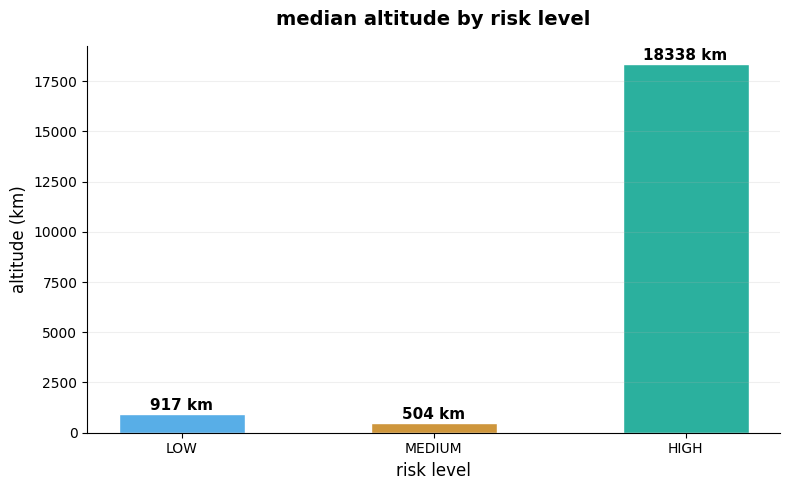

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

alt_means = merged.groupby('risk_label')['altitude_km'].median().reindex(['LOW', 'MEDIUM', 'HIGH'])
colors = ["#58aee7", "#ce963c", "#2bb09e"]

bars = ax.bar(alt_means.index, alt_means.values, color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, alt_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:.0f} km', ha='center', fontweight='bold', fontsize=11)

plt.title('median altitude by risk level', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('risk level', fontsize=12)
plt.ylabel('altitude (km)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [15]:
merged.to_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet", index=False)
print("saved with risk_label!!", merged.shape)
print(merged['risk_label'].value_counts())

saved with risk_label!! (66666, 55)
risk_label
LOW       26366
HIGH      24571
MEDIUM    15729
Name: count, dtype: int64
